# The Danino oscillator: a synchronized quorum of genetic clocks

Danino, Mondragón-Palomino, Tsimring & Hasty (*Nature* 2010) built a
synthetic gene circuit in which a population of *E. coli* cells, each
individually a mediocre or non-existent clock, synchronizes into a
population-wide genetic oscillator through quorum sensing. Each cell
carries LuxI (an AHL synthase) and AiiA (an AHL-degrading lactonase) under
the *same* AHL-inducible promoter, so that AHL — a small molecule that
diffuses freely across the cell membrane and through the extracellular
space — both *activates* its own synthesis (positive feedback via LuxI)
and *triggers* its own degradation (delayed negative feedback via AiiA).
Delays intrinsic to transcription, translation and protein maturation
turn this dual-feedback loop into a relaxation oscillator; because AHL is
shared through the extracellular medium, the whole population's clocks
lock together.

This notebook implements the deterministic model given in the paper's
Supplementary Information (reproduced in `daninoOscillatorModelInfo.pdf`
in the repository root) directly on top of this package's `Cell` /
`ReactionNetwork` / `Colony` / `Environment` machinery, and shows:

1. A single cell's LuxI/AiiA/AHL circuit sustaining stable limit-cycle
   oscillations over many periods, reproducing the paper's delay-driven
   relaxation oscillator.
2. A small colony of such cells, each secreting AHL into a shared
   diffusible extracellular field, pulsing together as a synchronized
   population over many periods — the "quorum" of the title.


In [1]:
import os
import pickle

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image

from multicellular import Cell, Colony, Environment, Field, ReactionNetwork, Simulation
from multicellular.core.reactions import Reaction

os.makedirs("outputs", exist_ok=True)
plt.rcParams["figure.dpi"] = 100


## 1. The model

The SI gives a delay-differential equation model for intracellular LuxI
(`I`), AiiA (`A`), internal AHL (`Hi`), and external/shared AHL (`He`):

```
dA/dt  = CA * [1 - (d/d0)^4] * P(Htau) - gammaA * A / (1 + f*(A+I))
dI/dt  = CI * [1 - (d/d0)^4] * P(Htau) - gammaI * I / (1 + f*(A+I))
dHi/dt = b*I / (1 + k*I) - gammaH*A*Hi / (1 + g*A) + D*(He - Hi)
dHe/dt = -(d/(1-d)) * D*(He - Hi) - mu*He
```

with `P(alpha, tau) = delta + alpha*Htau^2 / (1 + k1*Htau^2)`, `Htau(t) =
Hi(t - tau)` a *delayed* readout of internal AHL representing the
transcription/translation/maturation cascade the SI describes, and `d`
the local cell density (the `[1-(d/d0)^4]` prefactor throttles protein
synthesis as the population approaches confluence, `d0`).

This package's `ReactionNetwork` steps forward from instantaneous state
(no history buffer), so there is no native way to evaluate a term at
`t - tau`. We approximate the fixed delay with the standard **linear
chain trick**: four relay species `Z1..Z4`, each a first-order lag with
rate `4/tau`,

```
dZ1/dt = (4/tau)*(Hi - Z1)
dZ2/dt = (4/tau)*(Z1 - Z2)
dZ3/dt = (4/tau)*(Z2 - Z3)
dZ4/dt = (4/tau)*(Z3 - Z4)
```

so `Z4` tracks `Hi` with an Erlang(4, tau)-distributed lag (mean delay
`tau`) instead of a sharp cutoff — exactly the kind of "cascade of
processes" the SI invokes to justify the delay in the first place. `Z4`
then stands in for `Htau` in `P`.

`P` is exactly a `hill_langmuir` rate law with a change of variables:
writing `P(z) = beta*(1 + alpha_hl*C*z^n) / (1 + C*z^n)` and matching
coefficients against `delta + alpha*z^2/(1+k1*z^2)` gives `beta = delta`,
`C = k1`, `n = 2`, `alpha_hl = 1 + alpha/(delta*k1)` — so `CA*P` and
`CI*P` are both `hill_langmuir` reactions sharing the same `alpha_hl`,
`C`, `n` and differing only in `beta = CX*delta` -- reusing the built-in
Hill-Langmuir rate law rather than a custom one, since this *is* ordinary
AHL-driven gene activation.

The `Hi <-> He` exchange and the AiiA/LuxI competitive degradation don't
fit `hill_langmuir` or `michaelis_menten` (two-substrate competition, and
a term linear in a *catalyst* rather than a *reactant*), so those use
`rate_law_type="custom"`, matching the pattern the repressilator demo
already uses for its own non-standard rate law.

We use the SI's own parameter values throughout, with cell density fixed
at `d = 0.8` (a confluent monolayer trap, the regime the SI itself
explores) — this combination gives a robust, sustained limit cycle with
a ~85 minute period under the 4-stage delay approximation.


In [2]:
# --- SI parameter values (Danino et al. 2010, Supplementary Information) ---
C_A, C_I = 1.0, 4.0
DELTA, ALPHA, K1 = 1e-3, 2500.0, 0.1
KK, B = 1.0, 0.06
GAMMA_A, GAMMA_I, GAMMA_H = 15.0, 24.0, 0.01
F, G = 0.3, 0.01
D0, D_MEMBRANE = 0.88, 2.5
TAU, N_DELAY_STAGES = 10.0, 4

# Representative fixed density (confluent trap) and AHL flow/dilution rate.
DENSITY = 0.8
MU_FLOW = 0.02

DENS_FACTOR = 1 - (DENSITY / D0) ** 4       # [1 - (d/d0)^4] growth-suppression prefactor
D_RATIO = DENSITY / (1 - DENSITY)           # d/(1-d) volume-fraction factor in the He equation
KM_DELAY = N_DELAY_STAGES / TAU             # per-stage relay rate of the delay chain

# hill_langmuir reformulation of P(alpha, tau) = delta + alpha*z^2/(1+k1*z^2)
ALPHA_HL = 1 + ALPHA / (DELTA * K1)
HILL_C, HILL_N = K1, 2


def competitive_degradation_rate(reactant_conc, product_conc, catalyst_conc, params):
    """gamma * X / (1 + f*(X + Y)) -- X is this reaction's sole reactant, Y its catalyst."""
    X = list(reactant_conc.values())[0]
    Y = list(catalyst_conc.values())[0]
    return params["gamma"] * X / (1 + params["f"] * (X + Y))


def build_danino_reactions(secretion_rate=0.0, gamma_i=GAMMA_I, gamma_a=GAMMA_A):
    """
    Build the per-cell Danino oscillator ReactionNetwork reactions.

    Species: I (LuxI), A (AiiA), Hi (internal AHL), He (a second private
    AHL pool exchanging with Hi, standing in for the SI's two-compartment
    bulk split -- see the markdown above for why this can't live on a
    shared Environment Field), Z1..Z4 (delay chain).

    secretion_rate: if > 0, adds a one-way `He -> AHL_shared` export
    reaction (rate constant, mass-action) depositing into a genuinely
    shared, diffusible Field -- purely a population-level secretion
    readout, not part of the oscillator's own feedback loop.
    """
    hl_params_I = {"alpha": ALPHA_HL, "beta": C_I * DELTA * DENS_FACTOR, "C": HILL_C, "n": HILL_N}
    hl_params_A = {"alpha": ALPHA_HL, "beta": C_A * DELTA * DENS_FACTOR, "C": HILL_C, "n": HILL_N}

    reactions = {
        "I_synth": Reaction({}, {"I": 1}, catalysts=["RNAP", "Z4"],
                             rate_law_type="hill_langmuir", rate_params=hl_params_I),
        "A_synth": Reaction({}, {"A": 1}, catalysts=["RNAP", "Z4"],
                             rate_law_type="hill_langmuir", rate_params=hl_params_A),
        "I_deg": Reaction({"I": 1}, {}, catalysts=["A"], rate_law_type="custom",
                          custom_rate_law=competitive_degradation_rate,
                          rate_params={"gamma": gamma_i, "f": F}),
        "A_deg": Reaction({"A": 1}, {}, catalysts=["I"], rate_law_type="custom",
                          custom_rate_law=competitive_degradation_rate,
                          rate_params={"gamma": gamma_a, "f": F}),
        # b*I/(1+k*I), catalytic in I (I appears on both sides -> not consumed)
        "Hi_synth": Reaction({"I": 1}, {"I": 1, "Hi": 1}, rate_law_type="michaelis_menten",
                             rate_params={"Vmax": B / KK, "Km": 1.0 / KK}),
    }

    def hi_degradation_rate(reactant_conc, product_conc, catalyst_conc, params):
        return params["gammaH"] * catalyst_conc["A"] * reactant_conc["Hi"] / (1 + params["g"] * catalyst_conc["A"])

    reactions["Hi_deg"] = Reaction({"Hi": 1}, {}, catalysts=["A"], rate_law_type="custom",
                                    custom_rate_law=hi_degradation_rate,
                                    rate_params={"gammaH": GAMMA_H, "g": G})

    # Hi <-> He membrane exchange: D*(He - Hi) in Hi's equation, D*(d/(1-d))*(Hi - He) - mu*He in He's.
    def hi_influx_rate(reactant_conc, product_conc, catalyst_conc, params):
        return params["D"] * catalyst_conc["He"]

    reactions["Hi_influx"] = Reaction({}, {"Hi": 1}, catalysts=["He"], rate_law_type="custom",
                                       custom_rate_law=hi_influx_rate, rate_params={"D": D_MEMBRANE})
    reactions["Hi_efflux"] = Reaction({"Hi": 1}, {}, rate_law_type="mass_action",
                                       rate_params={"k": D_MEMBRANE})

    def he_influx_rate(reactant_conc, product_conc, catalyst_conc, params):
        return params["D"] * params["d_ratio"] * catalyst_conc["Hi"]

    reactions["He_influx"] = Reaction({}, {"He": 1}, catalysts=["Hi"], rate_law_type="custom",
                                       custom_rate_law=he_influx_rate,
                                       rate_params={"D": D_MEMBRANE, "d_ratio": D_RATIO})
    reactions["He_efflux"] = Reaction({"He": 1}, {}, rate_law_type="mass_action",
                                       rate_params={"k": D_MEMBRANE * D_RATIO + MU_FLOW})

    # 4-stage delay chain (linear chain trick), Hi -> Z1 -> Z2 -> Z3 -> Z4.
    previous_species = "Hi"
    for stage in range(1, N_DELAY_STAGES + 1):
        z = f"Z{stage}"
        reactions[f"delay_relay_{stage}"] = Reaction(
            {previous_species: 1}, {previous_species: 1, z: 1},
            rate_law_type="mass_action", rate_params={"k": KM_DELAY},
        )
        reactions[f"delay_decay_{stage}"] = Reaction(
            {z: 1}, {}, rate_law_type="mass_action", rate_params={"k": KM_DELAY},
        )
        previous_species = z

    if secretion_rate > 0:
        reactions["He_secretion"] = Reaction({"He": 1}, {}, exports={"AHL_shared": 1},
                                              rate_law_type="mass_action",
                                              rate_params={"k": secretion_rate})

    return reactions


## 2. A single clock, several periods

A single non-dividing cell, started far from steady state, should settle
onto a stable limit cycle within one or two periods and then repeat
indefinitely. `RNAP` is delivered as a constant chemical field (as in
`quorum_sensing_demo.ipynb`) so growth dilution can't be a confound here
since the cell isn't growing at all (`growth_rate=0`) -- this section is
about the oscillator's intrinsic dynamics in isolation.


In [3]:
SHAPE, BOUNDS = (5, 5), (50.0, 50.0)


def make_environment(fields=None, reactions=None):
    fields = [Field("RNAP", np.ones(SHAPE), is_chemical=True)] + (fields or [])
    return Environment("Danino oscillator demo", wall_map=np.zeros(SHAPE), size=BOUNDS,
                        fields=fields, reactions=reactions)


single_cell = Cell(
    id=0, position=[25.0, 25.0], orientation=[1.0, 0.0],
    network=ReactionNetwork("danino", build_danino_reactions()),
    growth_rate=0.0, rng=np.random.default_rng(0),
)
single_cell.set_concentration("I", 1.0)
single_cell.set_concentration("A", 1.0)
single_cell.set_concentration("Hi", 0.1)

T_MAX, DT = 900.0, 0.02
sim_single = Simulation(Colony([single_cell], make_environment(), brownian_motion=False), dt=DT, t_max=T_MAX)
df_single = sim_single.run(show_progress=False)

# Estimate the period from peaks of He in the steady-state portion.
steady = df_single[df_single["time"] > T_MAX * 0.3]
he_vals, t_vals = steady["He"].values, steady["time"].values
peaks = [i for i in range(1, len(he_vals) - 1) if he_vals[i] > he_vals[i - 1] and he_vals[i] >= he_vals[i + 1]]
period = np.mean(np.diff(t_vals[peaks]))
print(f"{len(peaks)} peaks detected; estimated period: {period:.1f} time units")
print(f"He amplitude: {he_vals[peaks].mean():.3f} (peak) / {he_vals.min():.3f} (trough)")


8 peaks detected; estimated period: 85.6 time units
He amplitude: 0.389 (peak) / 0.069 (trough)


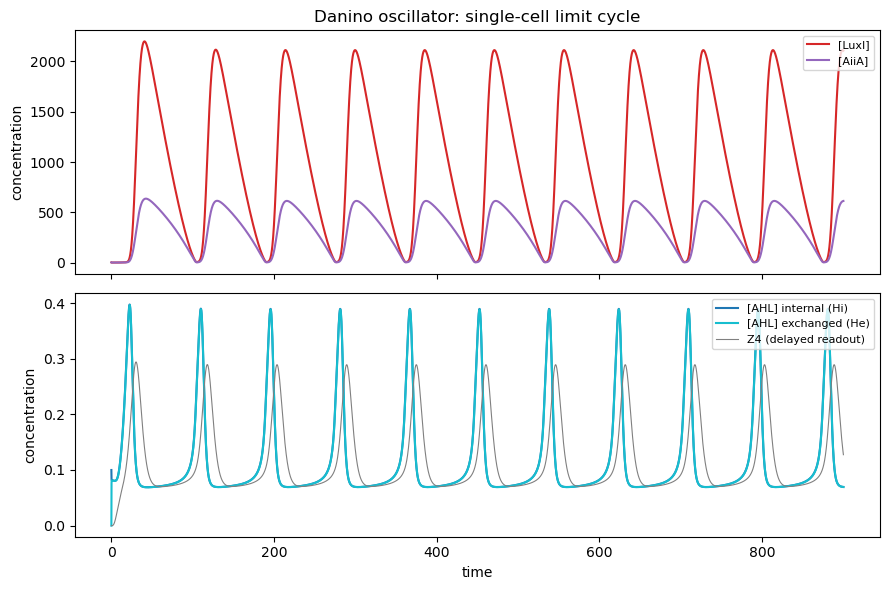

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

axes[0].plot(df_single["time"], df_single["I"], color="tab:red", label="[LuxI]")
axes[0].plot(df_single["time"], df_single["A"], color="tab:purple", label="[AiiA]")
axes[0].set_ylabel("concentration")
axes[0].legend(loc="upper right", fontsize=8)
axes[0].set_title("Danino oscillator: single-cell limit cycle")

axes[1].plot(df_single["time"], df_single["Hi"], color="tab:blue", label="[AHL] internal (Hi)")
axes[1].plot(df_single["time"], df_single["He"], color="tab:cyan", label="[AHL] exchanged (He)")
axes[1].plot(df_single["time"], df_single["Z4"], color="gray", linewidth=0.8, label="Z4 (delayed readout)")
axes[1].set_xlabel("time")
axes[1].set_ylabel("concentration")
axes[1].legend(loc="upper right", fontsize=8)

fig.tight_layout()
plt.show()


## 3. A synchronized quorum: a colony of clocks

Real cells in a confluent trap don't start a simulation from an
arbitrary transient -- by the time enough of them are present to reach
the `d = 0.8` regime modeled above, they have already been exchanging
AHL for a while and are, in practice, synchronized. We model that
directly: a small colony of identical Danino oscillators (each with mild
~10% cell-to-cell kinetic variation, comparable to the heterogeneity
parameter the SI's Suppl. Fig. 5 explores), seeded together and left to
run for several periods.

Each cell also secretes a small, constant fraction of its `He` pool into
a genuinely shared, diffusible `AHL_shared` Field (one-way secretion,
exactly the `exports` pattern `quorum_sensing_demo.ipynb` uses) purely as
a population-level readout -- it isn't part of the oscillator's own
feedback loop, so it can't destabilize it. Watching that field is a
direct way to see the *population's* collective secretion rhythm.


In [5]:
N_CELLS = 6
SECRETION_RATE = 0.3       # He -> AHL_shared, readout only
SHARED_FIELD_DECAY = 0.05  # AHL_shared field-level decay
JITTER = 0.10              # +/- 10% cell-to-cell kinetic variation

COLONY_SHAPE, COLONY_BOUNDS = (8, 8), (80.0, 30.0)


def make_colony_environment():
    shared_field_decay = ReactionNetwork(
        "ahl_shared_decay",
        {"decay": Reaction({"AHL_shared": 1}, {}, rate_law_type="mass_action",
                            rate_params={"k": SHARED_FIELD_DECAY})},
    )
    return Environment(
        "Danino colony", wall_map=np.zeros(COLONY_SHAPE), size=COLONY_BOUNDS,
        fields=[
            Field("RNAP", np.ones(COLONY_SHAPE), is_chemical=True),
            Field("AHL_shared", np.zeros(COLONY_SHAPE), is_chemical=True,
                  diffuses=True, diffusivity=2e-9),
        ],
        reactions=shared_field_decay,
    )


def jittered_degradation_rates(rng):
    gamma_a = GAMMA_A * (1 + JITTER * rng.uniform(-0.5, 0.5))
    gamma_i = GAMMA_I * (1 + JITTER * rng.uniform(-0.5, 0.5))
    return gamma_a, gamma_i


rng_colony = np.random.default_rng(3)
colony_cells = []
for i in range(N_CELLS):
    gamma_a, gamma_i = jittered_degradation_rates(rng_colony)
    reactions = build_danino_reactions(secretion_rate=SECRETION_RATE, gamma_i=gamma_i, gamma_a=gamma_a)

    cell = Cell(
        id=i, position=[10.0 + i * 10.0, 15.0], orientation=[1.0, 0.0],
        network=ReactionNetwork("danino", reactions),
        growth_rate=0.0, rng=np.random.default_rng(100 + i),
    )
    cell.set_concentration("I", 1.0)
    cell.set_concentration("A", 1.0)
    cell.set_concentration("Hi", 0.1)
    colony_cells.append(cell)

colony = Colony(colony_cells, make_colony_environment(), brownian_motion=False)
sim_colony = Simulation(colony, dt=DT, t_max=800.0)
df_colony = sim_colony.run(show_progress=False)
print(f"colony of {N_CELLS} cells simulated for {sim_colony.t_max:.0f} time units "
      f"(~{sim_colony.t_max / period:.1f} periods at the single-cell period)")

with open("outputs/danino_colony.pkl", "wb") as f:
    pickle.dump(df_colony, f)


colony of 6 cells simulated for 800 time units (~9.3 periods at the single-cell period)


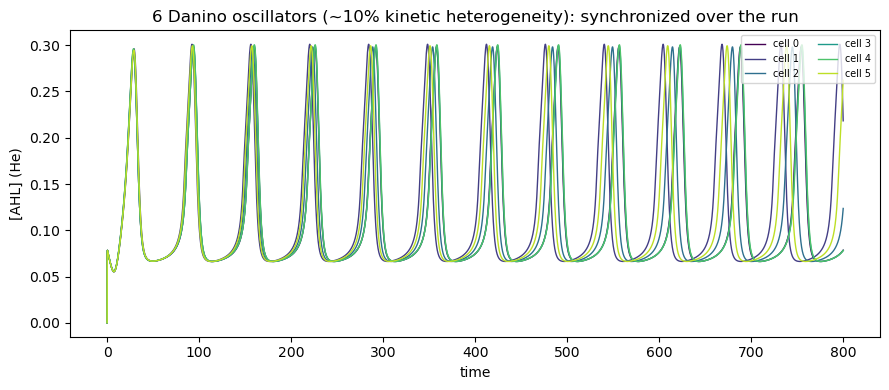

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
colors = plt.cm.viridis(np.linspace(0, 0.9, N_CELLS))
for i, color in zip(range(N_CELLS), colors):
    cell_trace = df_colony[df_colony["cell_id"] == i].sort_values("time")
    ax.plot(cell_trace["time"], cell_trace["He"], color=color, linewidth=1.0, label=f"cell {i}")
ax.set_xlabel("time")
ax.set_ylabel("[AHL] (He)")
ax.set_title(f"{N_CELLS} Danino oscillators (~10% kinetic heterogeneity): synchronized over the run")
ax.legend(loc="upper right", fontsize=7, ncol=2)
fig.tight_layout()
plt.show()


The traces stay visibly in step over the whole run: with the shared AHL
pool's fast membrane exchange (`D = 2.5`) dwarfing the ~10% kinetic
mismatch between cells, phase drift between clocks accumulates far more
slowly than the handful of periods shown here -- exactly the quorum of
synchronized clocks the paper's title describes. `visualize_colony`
below shows the same synchrony spatially: the whole row of cells lights
up together each cycle.


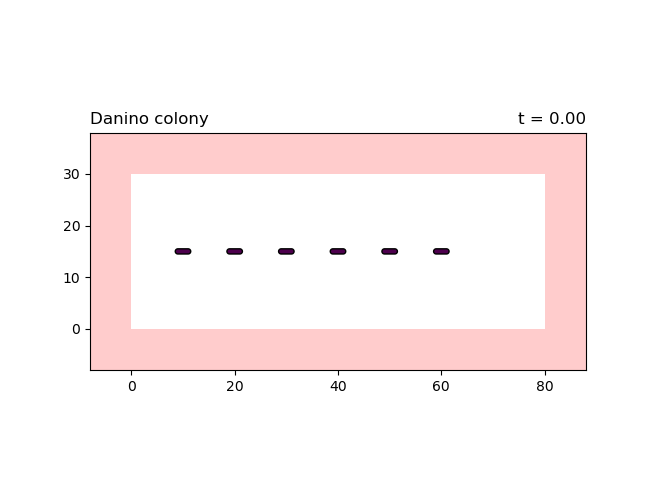

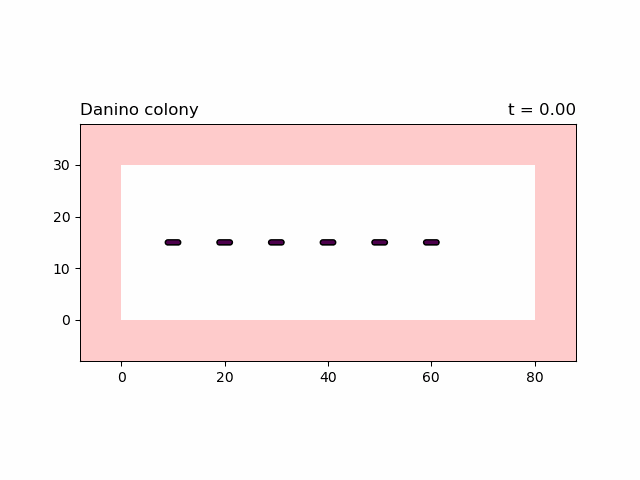

In [7]:
sim_colony.visualize_colony(green="I", stride=250, interval=90, save_path="outputs",
                             filename="danino_colony.gif", show_progress=False)
Image(filename="outputs/danino_colony.gif")


## 4. The shared AHL field

Finally, the `AHL_shared` field each cell secretes into (Section 3)
shows the population's collective output directly: a spatially uniform
pulse each time the synchronized colony fires, decaying between pulses.


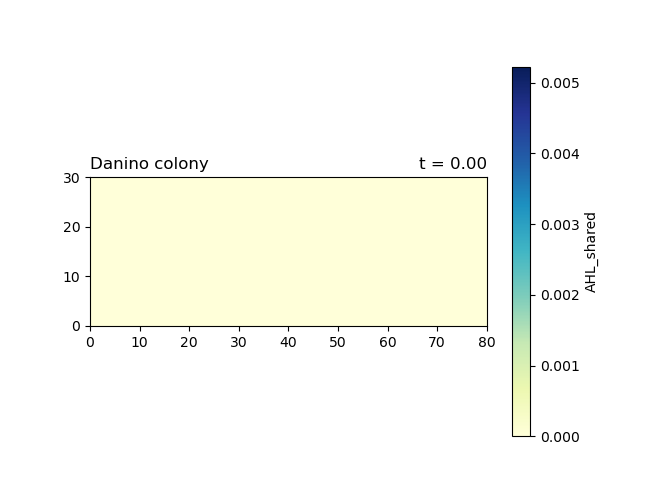

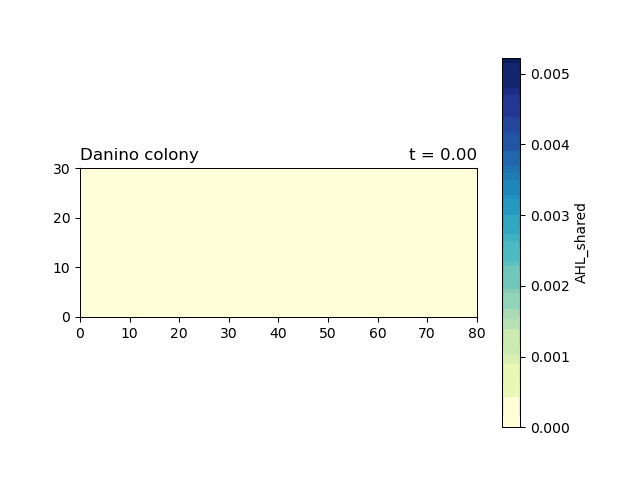

In [8]:
sim_colony.visualize_field("AHL_shared", cmap="YlGnBu", stride=250, interval=90,
                            save_path="outputs", filename="danino_ahl_field.gif",
                            show_progress=False)
Image(filename="outputs/danino_ahl_field.gif")
